# 实验四：线性搜索 - 寻找最优步长 $\alpha$

## 知识背景回顾

在前面的实验中，我们已经学习了梯度下降法（教材 4.2 节），其迭代公式为 $\mathbf{x}^{k+1} = \mathbf{x}^k + \alpha_k \mathbf{d}^k$，其中 $\mathbf{d}^k = -\nabla f(\mathbf{x}^k)$。我们当时使用的是一个固定的、需要手动调整的步长（学习率）$\alpha_k$。

然而，步长的选择至关重要：太大可能导致发散，太小则收敛缓慢。教材 **4.4 节 “线性搜索”** 专门探讨了如何更智能地确定每一步的“最优”步长 $\alpha_k$。

核心思想是，一旦方向 $\mathbf{d}^k$ 确定，寻找最优步长 $\alpha_k$ 就从一个 $n$ 维优化问题 $\min f(\mathbf{x})$ 转化为了一个**一维优化问题**：
$$\min_{\alpha \ge 0} \phi(\alpha) = f(\mathbf{x}^k + \alpha \mathbf{d}^k)$$
教材 将线性搜索分为两类：

1.  **4.4.1 精确线性搜索 (Exact Linear Search)**
    * **目标**：找到使 $\phi(\alpha)$ 真正最小的 $\alpha_k^*$，即 $\phi'(\alpha_k^*) = 0$。
    * **特点**：计算量大，在实践中不常用。对于梯度下降法，它有一个有趣的特性：$\nabla f(\mathbf{x}^{k+1})^T \mathbf{d}^k = 0$，即**连续两次迭代的梯度是正交的**。

2.  **4.4.2 非精确线性搜索 (Inexact Linear Search)**
    * **目标**：在实际中，我们不需要“完美”的 $\alpha_k$，只需要一个“足够好”的 $\alpha_k$，它能保证函数值**充分下降**，同时计算又快。
    * **Armijo-Goldstein 条件** (或充分下降条件)：这是为了防止 $\alpha_k$ **太大**。它要求 $\alpha_k$ 必须满足：
        $$\phi(\alpha) \le \phi(0) + c_1 \alpha \phi'(0)$$
        或者写成 $f$ 的形式：
        $$f(\mathbf{x}^k + \alpha \mathbf{d}^k) \le f(\mathbf{x}^k) + c_1 \alpha \nabla f(\mathbf{x}^k)^T \mathbf{d}^k$$
        其中 $c_1 \in (0, 1)$ 是一个小常数（如 0.1）。几何上，$\alpha_k$ 对应的新函数值必须位于初始切线 $L(\alpha) = \phi(0) + c_1 \alpha \phi'(0)$ 的下方。
    * **回溯线性搜索 (Backtracking Line Search)**：这是实现非精确搜索最常用的一种算法，它仅使用 Armijo 条件。
        * **算法**:
            1.  选择 $\alpha = \alpha_{init}$ (初始步长, 如 $\alpha=1$)，$\rho \in (0, 1)$ (缩小因子, 如 0.5)，$c_1 \in (0, 1)$。
            2.  **While** $\phi(\alpha) > \phi(0) + c_1 \alpha \phi'(0)$ **Do**
            3.  $\alpha \leftarrow \rho \alpha$ (回溯/缩小步长)
            4.  **End While**
            5.  返回 $\alpha_k = \alpha$。

## 实验说明

本实验分为两个模块，旨在让您深入理解线性搜索的原理和效果。

### 模块一：一维线性搜索与回溯法 (Backtracking) 交互模拟

* **目标**:
    1.  可视化从 2D 函数 $f(x, y)$ 沿着特定方向 $\mathbf{d}^k$ “切片”得到 1D 函数 $\phi(\alpha)$ 的过程。
    2.  在 1D 图像上直观理解 Armijo 条件的含义。
    3.  通过动画演示**回溯线性搜索**算法是如何通过迭代缩小 $\alpha$ 来找到满足 Armijo 条件的步长的。
* **交互内容**:
    1.  **选择函数**: 可以在“二次碗型函数”和“Rosenbrock 函数”之间切换。
    2.  **选择起点 $(x_k, y_k)$**: 通过滑杆在 2D 等高线图上选择一个起始点 $\mathbf{x}^k$。
    3.  **设置回溯参数**: 通过滑杆设置 Armijo 条件的参数 $c_1$ 和回溯法的缩小因子 $\rho$。
    4.  **运行动画**: 一个“运行回溯法”按钮。
* **可视化**:
    * **左图 (2D 视图)**: 显示 $f(x, y)$ 的等高线图。标记起点 $\mathbf{x}^k$，并沿搜索方向 $\mathbf{d}^k = -\nabla f(\mathbf{x}^k)$ 绘制一条直线。
    * **右图 (1D 视图)**: 实时绘制对应的 $\phi(\alpha) = f(\mathbf{x}^k + \alpha \mathbf{d}^k)$ 曲线。同时绘制 Armijo 条件直线 $L(\alpha) = \phi(0) + c_1 \alpha \phi'(0)$。
    * **动画**: 点击“运行”后，在右图上动态展示回溯法如何从 $\alpha=1.0$ 开始，检查是否满足条件（点是否在 $L(\alpha)$ 下方），若不满足则标记 'x'，然后缩小 $\alpha \leftarrow \rho \alpha$，直到找到一个满足条件的点并标记 '✓'。

### 模块二：非精确线性搜索条件 (Armijo & Wolfe) 可视化

* **目标**:
    1.  在一个固定的一维 $\phi(\alpha)$ 曲线上，直观理解 Armijo 条件的几何含义（防止 $\alpha$ 太大）。
    2.  直观理解 Wolfe 条件的几何含义（防止 $\alpha$ 太小）。
    3.  观察 $c_1$ 和 $c_2$ 参数如何改变“可接受步长”的区域。
* **交互内容**:
    1.  **设置参数**: 通过滑杆设置 Armijo 条件的参数 $c_1$ (范围 0 到 1) 和 Wolfe 条件的参数 $c_2$ (范围 $c_1$ 到 1)。
* **可视化**:
    * **上图 (Armijo 条件)**: 绘制 $\phi(\alpha)$ 曲线和 Armijo 线 $L(\alpha) = \phi(0) + c_1 \alpha \phi'(0)$。用阴影高亮显示所有满足 $\phi(\alpha) \le L(\alpha)$ 的“可接受” $\alpha$ 区域。
    * **下图 (Wolfe 条件)**: 绘制 $\phi(\alpha)$ 的**导数** $\phi'(\alpha)$ 曲线。绘制 $\phi'(0)$ 的 $c_2$ 倍水平线 $y = c_2 \phi'(0)$。用阴影高亮显示所有满足 $\phi'(\alpha) \ge c_2 \phi'(0)$ 的“可接受” $\alpha$ 区域。
* **观察重点**:
    * 调整 $c_1$ (Armijo)，观察上图中“足够下降”的区域如何变化？（$c_1$ 越小，要求越松，区域越大）。
    * 调整 $c_2$ (Wolfe)，观察下图中“曲率平坦”的区域如何变化？（$c_2$ 越大，要求越松，区域越大）。
    * 思考：一个“好”的步长 $\alpha_k$ 需要同时落在上下两个图的高亮区域内。

### 模块三：预设案例分析 - 不同搜索策略对比

* **目标**: 在 2D 平面上直观对比不同步长策略对梯度下降法**整体路径**的影响。
* **算例**: 我们使用“实验二”中熟悉的“二次碗型函数” $f(x, y) = x^2 + 10y^2$（一个病态条件函数） 和相同的初始点。
* **案例对比**:
    1.  **A: GD + 固定小步长 ($\alpha=0.01$)**: 步长太小，收敛缓慢。
    2.  **B: GD + 固定大步长 ($\alpha=0.098$)**: 步长接近不稳定的边缘，在山谷两侧剧烈震荡。
    3.  **C: GD + 精确线性搜索 (4.4.1节)**: 步长“完美”，但导致连续的梯度正交，呈现经典的“Z”字形（Zigzagging）路径，收敛也较慢。
    4.  **D: GD + 回溯线性搜索 (4.4.2节)**: 算法自动在山谷陡峭处选择小步长、平缓处选择大步长，通常能比精确搜索和固定步长更快地沿山谷方向收敛。
* **观察**: 对比四种策略的收敛速度和路径形态，理解为什么非精确线性搜索（如回溯法）在实践中是一种高效且稳健的选择。

In [11]:
# 导入所有需要的库
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interactive_output, Dropdown, FloatSlider, Checkbox, Button, VBox, HBox, Output, Layout,fixed
from IPython.display import display, clear_output
from scipy.optimize import fminbound  # 用于精确线性搜索
import time
import warnings

# --- Matplotlib 全局设置 ---
plt.rcParams['font.sans-serif'] = ['SimHei'] # 正确显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 正确显示负号
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# --- 定义函数 (复用实验二的函数) ---
def bowl_function(x, y):
    return x**2 + 10*y**2

def bowl_grad(x, y):
    return np.array([2*x, 20*y])

def rosenbrock_function(x, y):
    return (1-x)**2 + 100*(y-x**2)**2

def rosenbrock_grad(x, y):
    dx = -2*(1-x) - 400*x*(y-x**2)
    dy = 200*(y-x**2)
    return np.array([dx, dy])

# 函数字典
functions = {
    "二次碗型函数": {
        "func": bowl_function, "grad": bowl_grad, "x_range": (-5, 5), "y_range": (-2, 2), "levels": np.logspace(-1, 3, 20)
    },
    "Rosenbrock函数": {
        "func": rosenbrock_function, "grad": rosenbrock_grad, "x_range": (-2, 2), "y_range": (-1, 3), "levels": np.logspace(0, 3.5, 20)
    }
}

In [ ]:
# --- 模块一：交互式 1D 线性搜索与回溯法 ---
print("--- 模块一：一维线性搜索与回溯法 (Backtracking) 交互模拟 ---")

# 创建 UI 控件
func_name_w_ls = Dropdown(options=functions.keys(), description='选择函数:')
x_start_w_ls = FloatSlider(min=-5.0, max=5.0, step=0.1, value=4.0, description='x_k (起点x)')
y_start_w_ls = FloatSlider(min=-2.0, max=3.0, step=0.1, value=1.5, description='y_k (起点y)')
c1_w_ls = FloatSlider(min=0.01, max=0.9, step=0.01, value=0.1, description='c1 (Armijo)', layout=Layout(width='300px'))
rho_w_ls = FloatSlider(min=0.1, max=0.9, step=0.1, value=0.5, description='rho (缩小因子)', layout=Layout(width='300px'))
run_button_ls = Button(description='运行回溯法动画', button_style='success')
out_1d_search_ls = Output()

# 绘图函数
def plot_1d_search_interactive(func_name, x_k_val, y_k_val, c1, rho, b_run): # b_run 现在是一个布尔值
    with out_1d_search_ls:
        out_1d_search_ls.clear_output(wait=True)
        
        info = functions[func_name]
        f = info["func"]
        grad_f = info["grad"]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # --- 图 1: 2D 视图 ---
        x_grid = np.linspace(info["x_range"][0], info["x_range"][1], 100)
        y_grid = np.linspace(info["y_range"][0], info["y_range"][1], 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = f(X, Y)
        
        try:
            ax1.contour(X, Y, Z, levels=info["levels"], cmap='viridis', alpha=0.7)
        except ValueError:
            ax1.contour(X, Y, Z, levels=np.logspace(0, 8, 20), cmap='viridis', alpha=0.7)
            
        ax1.set_title(f'2D 视图: $f(x, y)$')
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        
        x_k = np.array([x_k_val, y_k_val])
        grad_k = grad_f(x_k[0], x_k[1])
        d_k = -grad_k
        
        ax1.plot(x_k[0], x_k[1], 'go', markersize=10, label='$\mathbf{x}^k$ (起点)')
        
        if np.linalg.norm(grad_k) < 1e-6 or grad_k.dot(d_k) >= 0:
            ax1.text(0.5, 0.5, '当前点梯度接近0或 $\mathbf{d}^k$ 不是下降方向\n请选择其他点', 
                     ha='center', va='center', transform=ax1.transAxes, color='red')
            ax2.text(0.5, 0.5, '无法进行线性搜索', 
                     ha='center', va='center', transform=ax2.transAxes, color='red')
            plt.tight_layout()
            plt.show()
            return

        d_k_norm = d_k / (np.linalg.norm(d_k) + 1e-8)
        line_points = np.array([x_k + a * d_k_norm * (info["x_range"][1] - info["x_range"][0]) / 2 for a in np.linspace(-0.5, 1.5, 2)])
        ax1.plot(line_points[:, 0], line_points[:, 1], 'k--', alpha=0.6, label='搜索方向 $\mathbf{d}^k$')
        
        ax1.legend(loc='upper right')
        ax1.grid(True)
        ax1.set_xlim(info["x_range"])
        ax1.set_ylim(info["y_range"])
        ax1.set_aspect('equal', adjustable='box')

        # --- 图 2: 1D 视图 ---
        phi = lambda alpha: f(x_k[0] + alpha * d_k[0], x_k[1] + alpha * d_k[1])
        phi_prime_0 = grad_k.dot(d_k)
        
        alpha_max_search = 1.5
        if func_name == "Rosenbrock函数" and abs(x_k[0]) < 1.5 and abs(y_k_val - x_k_val**2) < 0.5:
             alpha_max_search = 0.01
            
        alpha_range = np.linspace(0, alpha_max_search, 200)
        phi_vals = np.array([phi(a) for a in alpha_range])
        
        finite_mask = np.isfinite(phi_vals)
        if not np.any(finite_mask):
            ax2.text(0.5, 0.5, '函数值在此范围计算溢出 (inf)', 
                     ha='center', va='center', transform=ax2.transAxes, color='red')
            plt.tight_layout()
            plt.show()
            return
            
        phi_min_finite = np.min(phi_vals[finite_mask])
        phi_max_finite = np.max(phi_vals[finite_mask])
        
        armijo_line = phi(0) + c1 * alpha_range * phi_prime_0
        
        ax2.plot(alpha_range[finite_mask], phi_vals[finite_mask], label='$\phi(\\alpha) = f(\\mathbf{x}^k + \\alpha \\mathbf{d}^k)$')
        ax2.plot(alpha_range, armijo_line, 'r--', label=f'Armijo 线 $L(\\alpha) = \phi(0) + c_1 \\alpha \phi\'(0)$')
        ax2.plot(0, phi(0), 'go', markersize=10, label='$\phi(0) = f(\\mathbf{x}^k)$')
        
        alpha_exact = -1
        try:
            alpha_exact = fminbound(phi, 0, alpha_max_search)
            if np.isfinite(phi(alpha_exact)):
                ax2.plot(alpha_exact, phi(alpha_exact), 'm*', markersize=15, label=f'精确最小 $\\alpha^*$={alpha_exact:.3f}')
        except Exception:
            pass
        
        ax2.set_title('1D 视图: 线性搜索与回溯法')
        ax2.set_xlabel(r'步长 $\alpha$')
        ax2.set_ylabel(r'$\phi(\alpha)$')
        
        if b_run:
            alpha = 1.0
            max_bt_iter = 10
            found = False
            for i in range(max_bt_iter):
                if alpha < 1e-6: break
                
                phi_alpha = phi(alpha)
                L_alpha = phi(0) + c1 * alpha * phi_prime_0
                
                # ******** 修改：确保 phi_alpha 是有限值再绘图 ***********
                if np.isfinite(phi_alpha):
                    if phi_alpha <= L_alpha:
                        ax2.plot(alpha, phi_alpha, 'gv', markersize=10, label=f'找到 $\\alpha={alpha:.3f}$')
                        ax2.text(alpha, phi_alpha + 0.05 * (phi_max_finite - phi_min_finite), '✓', color='green', fontsize=15, ha='center')
                        found = True
                        break
                    else:
                        ax2.plot(alpha, phi_alpha, 'rx', markersize=10)
                        ax2.text(alpha, phi_alpha + 0.05 * (phi_max_finite - phi_min_finite), 'x', color='red', fontsize=15, ha='center')
                # ****************************************************
                alpha = rho * alpha
                
            if not found:
                ax2.text(0.5, 0.5, '回溯失败，未找到步长', 
                         ha='center', va='center', transform=ax2.transAxes, color='red')
        
        ax2.legend(loc='upper right', fontsize=8)
        ax2.grid(True)
        
        # ******** 修改 Y 轴范围设定 ********
        margin = 0.1 * (phi_max_finite - phi_min_finite) + 1e-6
        
        # 底部：取 精确最小值, phi曲线的最小值, Armijo线起点 中的最小者
        ylim_bottom = phi_min_finite - margin
        if alpha_exact != -1 and np.isfinite(phi(alpha_exact)):
            ylim_bottom = min(ylim_bottom, phi(alpha_exact) - margin)
        ylim_bottom = min(ylim_bottom, armijo_line[0] - margin) # armijo_line[0] is phi(0)
        
        # 顶部：取 phi(0), phi曲线的最大值, Armijo线起点 中的最大者
        ylim_top = phi(0) + margin
        ylim_top = max(ylim_top, phi_max_finite + margin) # <--- 关键补充
        ylim_top = max(ylim_top, armijo_line[0] + margin)
        
        if ylim_bottom >= ylim_top:
            ylim_top = ylim_bottom + 1.0 # Fallback
            
        ax2.set_ylim(ylim_bottom, ylim_top)
        # *****************************************
        ax2.set_xlim(0, alpha_max_search)

        plt.tight_layout()
        plt.show()

# (按钮回调和 display 的代码保持不变)
def on_run_button_clicked_ls(b):
    plot_1d_search_interactive(func_name_w_ls.value, x_start_w_ls.value, y_start_w_ls.value, 
                               c1_w_ls.value, rho_w_ls.value, True)

run_button_ls.on_click(on_run_button_clicked_ls)

interactive_plot_1d = interactive_output(plot_1d_search_interactive, {
    'func_name': func_name_w_ls, 'x_k_val': x_start_w_ls, 'y_k_val': y_start_w_ls, 
    'c1': c1_w_ls, 'rho': rho_w_ls, 'b_run': fixed(False)
})

ui_1d = VBox([
    HBox([func_name_w_ls, x_start_w_ls, y_start_w_ls]),
    HBox([c1_w_ls, rho_w_ls]),
    run_button_ls,
    out_1d_search_ls
])
display(ui_1d)

--- 模块一：一维线性搜索与回溯法 (Backtracking) 交互模拟 ---


In [ ]:
# --- 模块二：非精确线性搜索条件 (Armijo & Wolfe) 可视化 ---
print("\n--- 模块二：非精确线性搜索条件 (Armijo & Wolfe) 可视化 ---")

# 控件
c1_w_m2 = FloatSlider(min=0.01, max=0.99, step=0.01, value=0.1, description='c1 (Armijo)', layout=Layout(width='300px'))
c2_w_m2 = FloatSlider(min=0.02, max=1.0, step=0.01, value=0.9, description='c2 (Wolfe)', layout=Layout(width='300px'))
out_m2 = Output()

# 固定一个 phi 函数用于演示
phi_demo = lambda a: 0.5 * a**2 - a + 1
phi_prime_demo = lambda a: a - 1
phi_0 = phi_demo(0)
phi_prime_0 = phi_prime_demo(0)

# 绘图函数 (*** 这是修改后的版本 ***)
def plot_module2(c1, c2):
    with out_m2:
        out_m2.clear_output(wait=True)
        
        # 确保 c2 > c1
        if c2 <= c1:
            c2 = c1 + 0.01
            # 检查 c2 是否超过最大值，如果超过了，就重置 c1 (这是一个边缘情况)
            if c2 > c2_w_m2.max:
                c1 = c2_w_m2.max - 0.01
                c1_w_m2.value = c1
            c2_w_m2.value = c2
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7))
        
        alpha_range = np.linspace(0, 2.0, 200)
        phi_vals = phi_demo(alpha_range)
        
        # --- 上图: Armijo (Sufficient Decrease) ---
        armijo_line = phi_0 + c1 * alpha_range * phi_prime_0
        
        ax1.plot(alpha_range, phi_vals, label='$\phi(\\alpha)$')
        ax1.plot(alpha_range, armijo_line, 'r--', label=f'$L(\\alpha) = \phi(0) + c_1 \\alpha \phi\'(0)$')
        ax1.plot(0, phi_0, 'go', markersize=10)
        
        # 填充 Armijo 区域
        armijo_mask = phi_vals <= armijo_line
        
        # ******** 修改点 1 ********
        # 使用 \leq 替换 \le
        ax1.fill_between(alpha_range, phi_vals, armijo_line, where=armijo_mask, 
                         color='green', alpha=0.3, label=f'Armijo 可接受区域 ($\phi \leq L$)')
        # **************************
        
        ax1.set_title(f'1. Armijo (充分下降) 条件 ($c_1={c1:.2f}$)')
        ax1.set_xlabel(r'步长 $\alpha$')
        ax1.set_ylabel(r'$\phi(\alpha)$')
        ax1.legend()
        ax1.grid(True)
        
        # --- 下图: Wolfe (Curvature) ---
        phi_prime_vals = phi_prime_demo(alpha_range)
        wolfe_line_val = c2 * phi_prime_0
        
        ax2.plot(alpha_range, phi_prime_vals, label="$\phi'(\\alpha)$")
        ax2.axhline(wolfe_line_val, color='r', linestyle='--', label=f'$y = c_2 \phi\'(0)$ (={wolfe_line_val:.2f})')
        ax2.axhline(0, color='k', linestyle=':', alpha=0.5)
        ax2.plot(0, phi_prime_0, 'go', markersize=10)
        
        # 填充 Wolfe 区域
        wolfe_mask = phi_prime_vals >= wolfe_line_val
        
        # ******** 修改点 2 ********
        # 使用 \geq 替换 \ge，使用 \phi' 替换 \phi\'
        ax2.fill_between(alpha_range, phi_prime_vals, wolfe_line_val, where=wolfe_mask,
                         color='blue', alpha=0.3, label=f'Wolfe 可接受区域 ($\phi\' \geq c_2 \phi\'(0)$)')
        # **************************

        ax2.set_title(f'2. Wolfe (曲率) 条件 ($c_2={c2:.2f}$)')
        ax2.set_xlabel(r'步长 $\alpha$')
        ax2.set_ylabel(r"$\phi'(\alpha)$")
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()

# 链接控件 (保持不变)
interactive_plot_m2 = interactive_output(plot_module2, {
    'c1': c1_w_m2, 'c2': c2_w_m2
})
ui_m2 = VBox([HBox([c1_w_m2, c2_w_m2]), out_m2])
display(ui_m2)


--- 模块二：非精确线性搜索条件 (Armijo & Wolfe) 可视化 ---



--- 模块三：预设案例分析 - 不同搜索策略对比 ---


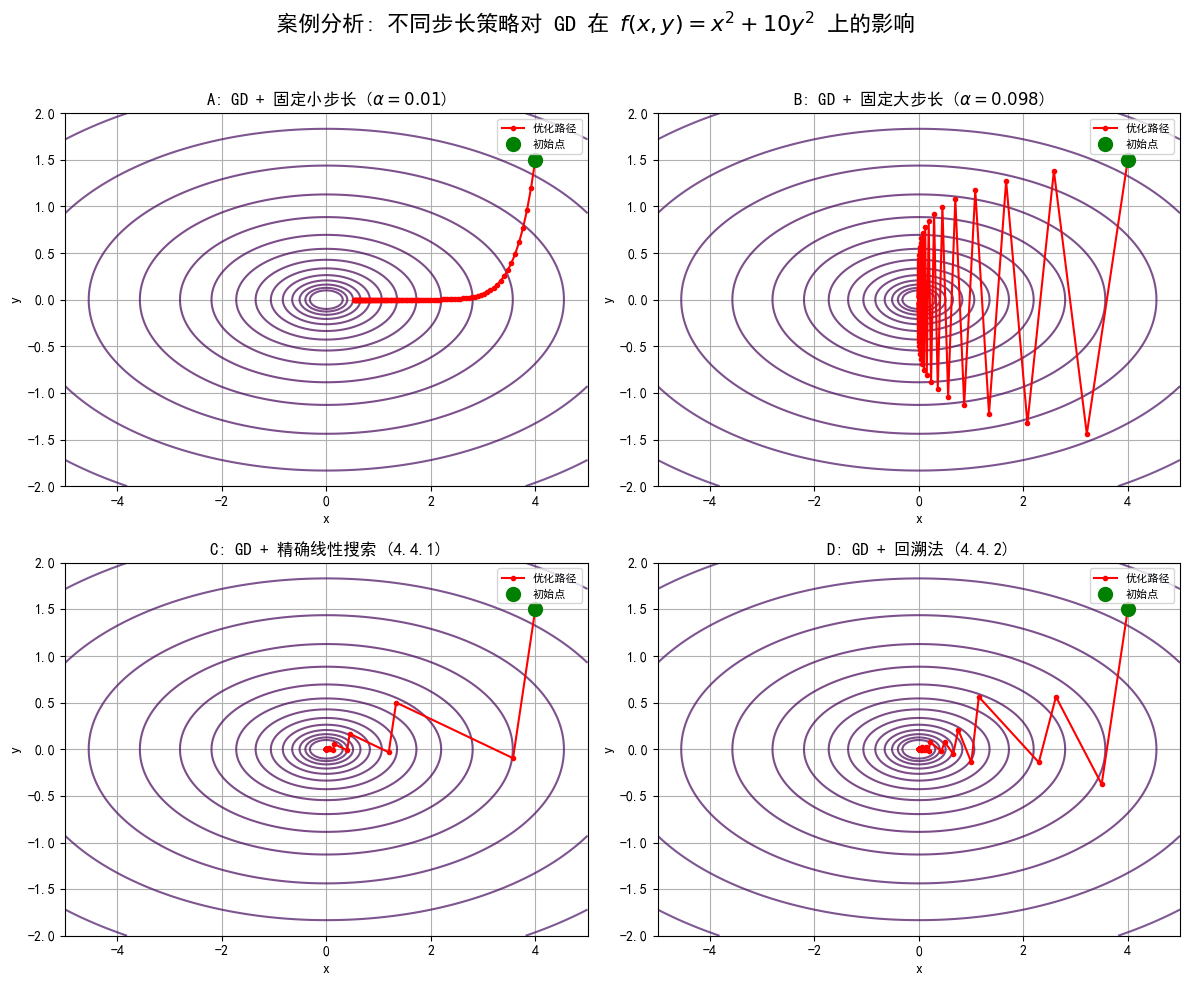

In [14]:
# --- 模块三：预设案例分析 - 不同搜索策略对比 ---
print("\n--- 模块三：预设案例分析 - 不同搜索策略对比 ---")

# (run_gd_exact, run_gd_backtracking, run_gd_fixed 函数定义保持不变)
# 1. 精确搜索
def run_gd_exact(f, grad_f, start_point, n_iterations, x_range, y_range):
    path = [start_point]
    x_k = np.array(start_point, dtype=float)
    for _ in range(n_iterations):
        grad_k = grad_f(x_k[0], x_k[1])
        d_k = -grad_k
        if np.linalg.norm(d_k) < 1e-6:
            break
        
        phi = lambda alpha: f(x_k[0] + alpha * d_k[0], x_k[1] + alpha * d_k[1])
        
        alpha_max = 1.0
        try:
            while f(x_k[0] + alpha_max * d_k[0], x_k[1] + alpha_max * d_k[1]) < f(x_k[0], x_k[1]):
                alpha_max *= 2.0
                if alpha_max > 100: break
        except Exception: # 捕获可能的溢出
            alpha_max = 1.0 # 如果溢出，回退到 1.0
            
        alpha_k = fminbound(phi, 0, alpha_max)
        
        x_k = x_k + alpha_k * d_k
        path.append(x_k)
    return np.array(path)

# 2. 回溯法
def run_gd_backtracking(f, grad_f, start_point, n_iterations, c1=0.1, rho=0.5):
    path = [start_point]
    x_k = np.array(start_point, dtype=float)
    for _ in range(n_iterations):
        grad_k = grad_f(x_k[0], x_k[1])
        d_k = -grad_k
        if np.linalg.norm(grad_k) < 1e-6:
            break
        
        alpha_k = 1.0 # 初始步长
        phi_0 = f(x_k[0], x_k[1])
        phi_prime_0 = grad_k.dot(d_k)
        
        bt_iter = 0
        while f(x_k[0] + alpha_k * d_k[0], x_k[1] + alpha_k * d_k[1]) > phi_0 + c1 * alpha_k * phi_prime_0:
            alpha_k = rho * alpha_k
            bt_iter += 1
            if bt_iter > 30: 
                alpha_k = 0
                break
        
        if alpha_k == 0:
            break
            
        x_k = x_k + alpha_k * d_k
        path.append(x_k)
    return np.array(path)

# 3. 固定步长
def run_gd_fixed(grad_func, start_point, learning_rate, n_iterations):
    path = [start_point]
    point = np.array(start_point, dtype=float)
    for _ in range(n_iterations):
        grad = grad_func(point[0], point[1])
        point = point - learning_rate * grad
        path.append(point.copy())
        if np.linalg.norm(grad) < 1e-6:
            break
    return np.array(path)

# --- 绘制案例图 ---
fig_cases, axes = plt.subplots(2, 2, figsize=(12, 10))
fig_cases.suptitle('案例分析: 不同步长策略对 GD 在 $f(x,y)=x^2+10y^2$ 上的影响', fontsize=16)
info_bowl = functions["二次碗型函数"]
f, grad_f = info_bowl["func"], info_bowl["grad"]
x_range, y_range, levels = info_bowl["x_range"], info_bowl["y_range"], info_bowl["levels"]
start_pt = (4, 1.5)

x_grid = np.linspace(x_range[0], x_range[1], 200)
y_grid = np.linspace(y_range[0], y_range[1], 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

# 封装绘图 (*** 这是修改后的版本 ***)
def plot_path_on_ax(ax, path, title):
    ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.7)
    ax.plot(path[:, 0], path[:, 1], '-o', color='red', markersize=3, label='优化路径')
    ax.plot(start_pt[0], start_pt[1], 'go', markersize=10, label='初始点')
    ax.set_title(title) # 标题现在由调用者提供
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    ax.legend(fontsize=8)
# ***********************************

# A: 固定小步长
path_A = run_gd_fixed(grad_f, start_pt, 0.01, 100)
# ******** 修改标题格式 ********
plot_path_on_ax(axes[0, 0], path_A, "A: GD + 固定小步长 ($\\alpha=0.01$)")

# B: 固定大步长 (震荡)
path_B = run_gd_fixed(grad_f, start_pt, 0.098, 100)
# ******** 修改标题格式 ********
plot_path_on_ax(axes[0, 1], path_B, "B: GD + 固定大步长 ($\\alpha=0.098$)")

# C: 精确线性搜索
path_C = run_gd_exact(f, grad_f, start_pt, 100, x_range, y_range)
plot_path_on_ax(axes[1, 0], path_C, "C: GD + 精确线性搜索 (4.4.1)")

# D: 回溯线性搜索
path_D = run_gd_backtracking(f, grad_f, start_pt, 100)
plot_path_on_ax(axes[1, 1], path_D, "D: GD + 回溯法 (4.4.2)")
# ***********************************

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



- **图 A (固定小步长):** 路径平滑，但步子太小，100 次迭代后远未收敛。
- **图 B (固定大步长):** 步长过大，导致在狭窄的山谷（y方向曲率大）两侧剧烈震荡，收敛缓慢。
- **图 C (精确搜索):** 严格遵循教材 4.4.1 节提到的连续梯度正交特性，在病态函数的山谷中呈现出典型的“Z”字形（Zigzagging）路径，收敛效率低下。
- **图 D (回溯法):** 算法自动调整了步长。在陡峭处（开始时）步长较小，进入山谷平缓处（x方向）步长变大，它能比精确搜索和固定步长更快地沿着山谷底部移动，收敛效果最好。这证明了非精确线性搜索（如回溯法）在实践中的优越性。
